In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os

path = "/content/drive/MyDrive/Glance_Assignment/images"

print("Exists:", os.path.exists(path))
print("Number of images:", len(os.listdir(path)))

Exists: True
Number of images: 3198


In [7]:
!pip -q install transformers sentence-transformers faiss-cpu accelerate pillow tqdm matplotlib
!pip -q install git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.8 MB/s eta 0:00:00


In [8]:
import torch
import clip
import faiss
import transformers

print("Torch:", torch.__version__)
print("CLIP imported successfully")
print("FAISS imported successfully")
print("Transformers:", transformers.__version__)
print("GPU Available:", torch.cuda.is_available())

Torch: 2.11.0+cu128
CLIP imported successfully
FAISS imported successfully
Transformers: 5.12.1
GPU Available: True


Total Images: 3198
/content/drive/MyDrive/Glance_Assignment/images/003d41dd20f271d27219fe7ee6de727d.jpg


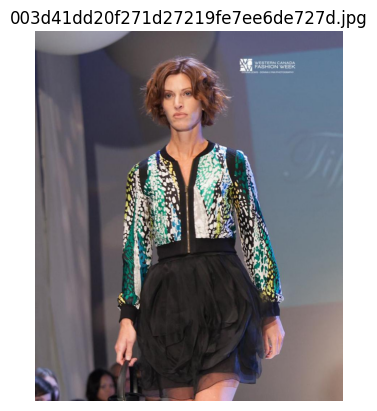

In [9]:
import os
from PIL import Image
import matplotlib.pyplot as plt

IMAGE_DIR = "/content/drive/MyDrive/Glance_Assignment/images"

image_files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print("Total Images:", len(image_files))

sample_path = os.path.join(IMAGE_DIR, image_files[0])

img = Image.open(sample_path)

plt.imshow(img)
plt.axis("off")
plt.title(image_files[0])

print(sample_path)

In [10]:
import torch
import clip

device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load("ViT-B/32", device=device)

print("Using device:", device)
print("CLIP loaded successfully!")

100%|████████████████████████████████████████| 338M/338M [00:03<00:00, 105MiB/s]


Using device: cuda
CLIP loaded successfully!


In [11]:
import os
import torch
from PIL import Image
from tqdm import tqdm

IMAGE_DIR = "/content/drive/MyDrive/Glance_Assignment/images"

sample_images = sorted(os.listdir(IMAGE_DIR))[:10]

image_embeddings = []

for image_name in tqdm(sample_images):
    image_path = os.path.join(IMAGE_DIR, image_name)

    image = preprocess(Image.open(image_path).convert("RGB")).unsqueeze(0).to(device)

    with torch.no_grad():
        features = model.encode_image(image)
        features /= features.norm(dim=-1, keepdim=True)

    image_embeddings.append(features.cpu())

print("Encoded Images:", len(image_embeddings))
print("Embedding Shape:", image_embeddings[0].shape)

100%|██████████| 10/10 [00:03<00:00,  2.72it/s]

Encoded Images: 10
Embedding Shape: torch.Size([1, 512])


In [12]:
from transformers import BlipProcessor, BlipForConditionalGeneration
import torch
from PIL import Image
from tqdm import tqdm
import os

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

captions = {}

for image_name in tqdm(sample_images):
    image_path = os.path.join(IMAGE_DIR, image_name)

    image = Image.open(image_path).convert("RGB")

    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        out = blip_model.generate(**inputs, max_new_tokens=25)

    caption = processor.decode(out[0], skip_special_tokens=True)

    captions[image_name] = caption

for k, v in list(captions.items())[:5]:
    print(k, "->", v)

HTTP Error 504 thrown while requesting HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/chat_template.json
Retrying in 1s [Retry 1/5].
HTTP Error 504 thrown while requesting HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/chat_template.json
Retrying in 2s [Retry 2/5].
HTTP Error 504 thrown while requesting HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/chat_template.json
Retrying in 4s [Retry 3/5].


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

100%|██████████| 10/10 [00:06<00:00,  1.66it/s]

003d41dd20f271d27219fe7ee6de727d.jpg -> a model walks the runway at the fashion show
0046f98599f05fd7233973e430d6d04d.jpg -> a model walks the runway at the person show
004e9e21cd1aca568a8ffc77a54638ce.jpg -> a model walks the runway at the fashion show
005b37fce3c0f641d327d95dd832f51b.jpg -> a woman in a white shirt and blue pants
0094940c58c343b742f48ae26eb5e9fa.jpg -> a model walks the runway at the fashion show


In [13]:
import os
import json
from PIL import Image
from tqdm import tqdm
import torch

IMAGE_DIR = "/content/drive/MyDrive/Glance_Assignment/images"
OUTPUT_DIR = "/content/drive/MyDrive/Glance_Assignment/output"

os.makedirs(OUTPUT_DIR, exist_ok=True)

CAPTION_FILE = os.path.join(OUTPUT_DIR, "captions.json")

# Load existing captions if resuming
if os.path.exists(CAPTION_FILE):
    with open(CAPTION_FILE, "r") as f:
        captions = json.load(f)
    print(f"Resuming from {len(captions)} captions")
else:
    captions = {}

image_files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

for idx, image_name in enumerate(tqdm(image_files)):

    if image_name in captions:
        continue

    image_path = os.path.join(IMAGE_DIR, image_name)

    try:
        image = Image.open(image_path).convert("RGB")

        inputs = processor(images=image, return_tensors="pt").to(device)

        with torch.no_grad():
            output = blip_model.generate(
                **inputs,
                max_new_tokens=25
            )

        caption = processor.decode(
            output[0],
            skip_special_tokens=True
        )

        captions[image_name] = caption

    except Exception as e:
        captions[image_name] = f"ERROR: {e}"

    # Save every 50 images
    if idx % 50 == 0:
        with open(CAPTION_FILE, "w") as f:
            json.dump(captions, f, indent=4)

# Final save
with open(CAPTION_FILE, "w") as f:
    json.dump(captions, f, indent=4)

print("Done!")
print("Total captions:", len(captions))

Resuming from 3198 captions


100%|██████████| 3198/3198 [00:00<00:00, 1163548.25it/s]

Done!
Total captions: 3198


In [14]:
import json
import re
import os

OUTPUT_DIR = "/content/drive/MyDrive/Glance_Assignment/output"

with open(os.path.join(OUTPUT_DIR, "captions.json"), "r") as f:
    captions = json.load(f)

colors = [
    "black","white","red","blue","green","yellow",
    "brown","gray","grey","pink","orange","purple",
    "beige","gold","silver","navy"
]

clothing = [
    "shirt","t-shirt","tee","blazer","jacket",
    "hoodie","coat","raincoat","dress",
    "skirt","jeans","pants","trousers",
    "shorts","tie","suit","sweater",
    "cardigan","boots","shoes","heels",
    "sneakers","hat","cap"
]

scene_keywords = {
    "office":"office",
    "park":"park",
    "street":"street",
    "runway":"fashion show",
    "fashion show":"fashion show",
    "home":"home",
    "room":"home",
    "city":"city"
}

style_keywords = {
    "blazer":"formal",
    "tie":"formal",
    "suit":"formal",
    "office":"formal",
    "hoodie":"casual",
    "t-shirt":"casual",
    "tee":"casual",
    "jeans":"casual",
    "shorts":"casual",
    "dress":"fashion",
    "runway":"fashion"
}

metadata = {}

for image_name, caption in captions.items():

    text = caption.lower()

    img_colors = [c for c in colors if c in text]
    img_clothing = [c for c in clothing if c in text]

    scene = "unknown"
    for k,v in scene_keywords.items():
        if k in text:
            scene = v
            break

    style = "unknown"
    for k,v in style_keywords.items():
        if k in text:
            style = v
            break

    metadata[image_name] = {
        "caption": caption,
        "colors": img_colors,
        "clothing": img_clothing,
        "scene": scene,
        "style": style
    }

with open(os.path.join(OUTPUT_DIR,"metadata.json"),"w") as f:
    json.dump(metadata,f,indent=4)

print("Metadata created for",len(metadata),"images")

Metadata created for 3198 images


In [15]:
import random
import json
import os

with open("/content/drive/MyDrive/Glance_Assignment/output/metadata.json") as f:
    metadata = json.load(f)

sample = random.sample(list(metadata.keys()),5)

for s in sample:
    print("="*70)
    print(s)
    print(metadata[s])

a574c19b024432fe08c97ad04c2aeea5.jpg
{'caption': 'a woman walking down a sidewalk holding an umbrella', 'colors': [], 'clothing': [], 'scene': 'unknown', 'style': 'unknown'}
e9e415310c10ee05c1ebbf0f013c9269.jpg
{'caption': 'a woman laying on a stone bench in the woods', 'colors': [], 'clothing': [], 'scene': 'unknown', 'style': 'unknown'}
5049bbdf74bd262be2a884d048d09619.jpg
{'caption': 'a woman in a white dress on a runway', 'colors': ['white'], 'clothing': ['dress'], 'scene': 'fashion show', 'style': 'fashion'}
0a4aae5ecd970a120bfcc6b377b6e187.jpg
{'caption': 'a model walks the runway at the fashion show', 'colors': [], 'clothing': [], 'scene': 'fashion show', 'style': 'fashion'}
963999a4ce820148817057ade3cc956d.jpg
{'caption': 'a model walks the ramp at the lakm fashion week 2013 in new delhi', 'colors': [], 'clothing': [], 'scene': 'unknown', 'style': 'unknown'}


In [16]:
!pip -q install bitsandbytes sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.9 MB/s eta 0:00:00


In [ ]:
!nvidia-smi

Thu Jul 16 06:49:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P0             30W /   70W |    1491MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [17]:
!pip -q install open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.8 MB/s eta 0:00:00


In [ ]:
import torch
import open_clip

device = "cuda" if torch.cuda.is_available() else "cpu"

model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-H-14",
    pretrained="laion2b_s32b_b79k"
)

tokenizer = open_clip.get_tokenizer("ViT-H-14")

model = model.to(device)
model.eval()

print("OpenCLIP loaded successfully!")

open_clip_model.safetensors:   0%|          | 0.00/3.94G [00:00<?, ?B/s]

OpenCLIP loaded successfully!


In [20]:
import os
import json
import numpy as np
from PIL import Image
from tqdm import tqdm
import torch
import open_clip

device = "cuda" if torch.cuda.is_available() else "cpu"

model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-H-14",
    pretrained="laion2b_s32b_b79k"
)

tokenizer = open_clip.get_tokenizer("ViT-H-14")

model = model.to(device)
model.eval()

IMAGE_DIR = "/content/drive/MyDrive/Glance_Assignment/images"
OUTPUT_DIR = "/content/drive/MyDrive/Glance_Assignment/output"

with open(os.path.join(OUTPUT_DIR, "captions.json")) as f:
    captions = json.load(f)

image_files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

embeddings = []
filenames = []

for image_name in tqdm(image_files):

    image = preprocess(
        Image.open(os.path.join(IMAGE_DIR, image_name)).convert("RGB")
    ).unsqueeze(0).to(device)

    text = tokenizer([captions[image_name]]).to(device)

    with torch.no_grad():

        image_feature = model.encode_image(image)
        text_feature = model.encode_text(text)

        image_feature /= image_feature.norm(dim=-1, keepdim=True)
        text_feature /= text_feature.norm(dim=-1, keepdim=True)

        feature = (
            0.7 * image_feature +
            0.3 * text_feature
        )

        feature /= feature.norm(dim=-1, keepdim=True)

    embeddings.append(feature.cpu().numpy()[0])
    filenames.append(image_name)

embeddings = np.array(embeddings).astype("float32")

print(embeddings.shape)

open_clip_model.safetensors:   0%|          | 0.00/3.94G [00:00<?, ?B/s]

100%|██████████| 3198/3198 [11:51<00:00,  4.49it/s]

(3198, 1024)


In [21]:
    import faiss
import numpy as np
import os
import json

OUTPUT_DIR="/content/drive/MyDrive/Glance_Assignment/output"

# Create FAISS index
dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)

index.add(embeddings)

print("Vectors stored:", index.ntotal)

# Save index
faiss.write_index(index,
                  os.path.join(OUTPUT_DIR,"fashion.index"))

# Save filename mapping
with open(os.path.join(OUTPUT_DIR,"filenames.json"),"w") as f:
  json.dump(filenames,f)

# Save embeddings (optional but useful)
np.save(os.path.join(OUTPUT_DIR,"embeddings.npy"),
        embeddings)

print("Everything saved successfully!")

Vectors stored: 3198
Everything saved successfully!


In [22]:
import os
import json
!pip install faiss-cpu
import faiss
import numpy as np

OUTPUT_DIR="/content/drive/MyDrive/Glance_Assignment/output"

index = faiss.read_index(os.path.join(OUTPUT_DIR,"fashion.index"))

with open(os.path.join(OUTPUT_DIR,"filenames.json")) as f:
    filenames = json.load(f)

with open(os.path.join(OUTPUT_DIR,"metadata.json")) as f:
    metadata = json.load(f)

print(index.ntotal)
print(len(filenames))
print(len(metadata))

3198
3198
3198


In [23]:
def encode_query(query):

    tokens = tokenizer([query]).to(device)

    with torch.no_grad():

        features = model.encode_text(tokens)

        features /= features.norm(dim=-1, keepdim=True)

    return features.cpu().numpy().astype("float32")

In [24]:
query = "a person wearing a blue shirt"

embedding = encode_query(query)

print(embedding.shape)

(1, 1024)


In [25]:
def retrieve_candidates(query, top_k=50):

    query_embedding = encode_query(query)

    scores, indices = index.search(query_embedding, top_k)

    candidates = []

    for score, idx in zip(scores[0], indices[0]):

        filename = filenames[idx]

        candidates.append({
            "filename": filename,
            "score": float(score),
            "metadata": metadata[filename]
        })

    return candidates

In [26]:
query = "professional business attire inside a modern office"

candidates = retrieve_candidates(query)

print("Retrieved:", len(candidates))

print(candidates[0])

Retrieved: 50
{'filename': 'ac9cf5f349291912f5a973202b51da55.jpg', 'score': 0.335279256105423, 'metadata': {'caption': 'a woman in a black suit and white shirt', 'colors': ['black', 'white'], 'clothing': ['shirt', 'suit'], 'scene': 'unknown', 'style': 'formal'}}


In [27]:
colors = [
    "black","white","red","blue","green","yellow",
    "brown","gray","grey","pink","orange","purple",
    "beige","gold","silver","navy"
]

clothing = [
    "shirt","t-shirt","tee","blazer","jacket",
    "hoodie","coat","raincoat","dress",
    "skirt","jeans","pants","trousers",
    "shorts","tie","suit","sweater",
    "cardigan","boots","shoes","heels",
    "sneakers","hat","cap"
]

scene_keywords = {
    "office":"office",
    "park":"park",
    "street":"street",
    "city":"city",
    "home":"home",
    "room":"home",
    "runway":"fashion show"
}

style_keywords = {
    "formal":"formal",
    "business":"formal",
    "casual":"casual",
    "weekend":"casual",
    "fashion":"fashion"
}

def parse_query(query):

    text = query.lower()

    q = {
        "colors":[c for c in colors if c in text],
        "clothing":[c for c in clothing if c in text],
        "scene":"unknown",
        "style":"unknown"
    }

    for k,v in scene_keywords.items():
        if k in text:
            q["scene"] = v
            break

    for k,v in style_keywords.items():
        if k in text:
            q["style"] = v
            break

    return q

In [28]:
parse_query(
    "professional business attire inside a modern office"
)

{'colors': [], 'clothing': [], 'scene': 'office', 'style': 'formal'}

In [29]:
def rerank(candidates, query_info):

    for item in candidates:

        bonus = 0

        meta = item["metadata"]

        # Scene
        if query_info["scene"] != "unknown":
            if meta["scene"] == query_info["scene"]:
                bonus += 0.20

        # Style
        if query_info["style"] != "unknown":
            if meta["style"] == query_info["style"]:
                bonus += 0.15

        # Clothing
        overlap = set(query_info["clothing"]) & set(meta["clothing"])
        bonus += 0.05 * len(overlap)

        # Colors
        overlap = set(query_info["colors"]) & set(meta["colors"])
        bonus += 0.05 * len(overlap)

        item["final_score"] = item["score"] + bonus

    candidates.sort(
        key=lambda x: x["final_score"],
        reverse=True
    )

    return candidates

In [30]:
query = "professional business attire inside a modern office"

info = parse_query(query)

results = rerank(
    retrieve_candidates(query),
    info
)

print(results[0])

{'filename': 'ac9cf5f349291912f5a973202b51da55.jpg', 'score': 0.335279256105423, 'metadata': {'caption': 'a woman in a black suit and white shirt', 'colors': ['black', 'white'], 'clothing': ['shirt', 'suit'], 'scene': 'unknown', 'style': 'formal'}, 'final_score': 0.485279256105423}


In [31]:
import matplotlib.pyplot as plt
from PIL import Image
import os

def show_results(results, n=5):

    plt.figure(figsize=(18,8))

    for i, item in enumerate(results[:n]):

        img = Image.open(
            os.path.join(
                IMAGE_DIR,
                item["filename"]
            )
        )

        plt.subplot(1,n,i+1)

        plt.imshow(img)

        plt.axis("off")

        plt.title(
            f"Score:{item['final_score']:.2f}\n"
            f"{item['metadata']['caption']}",
            fontsize=8
        )

    plt.tight_layout()

    plt.show()

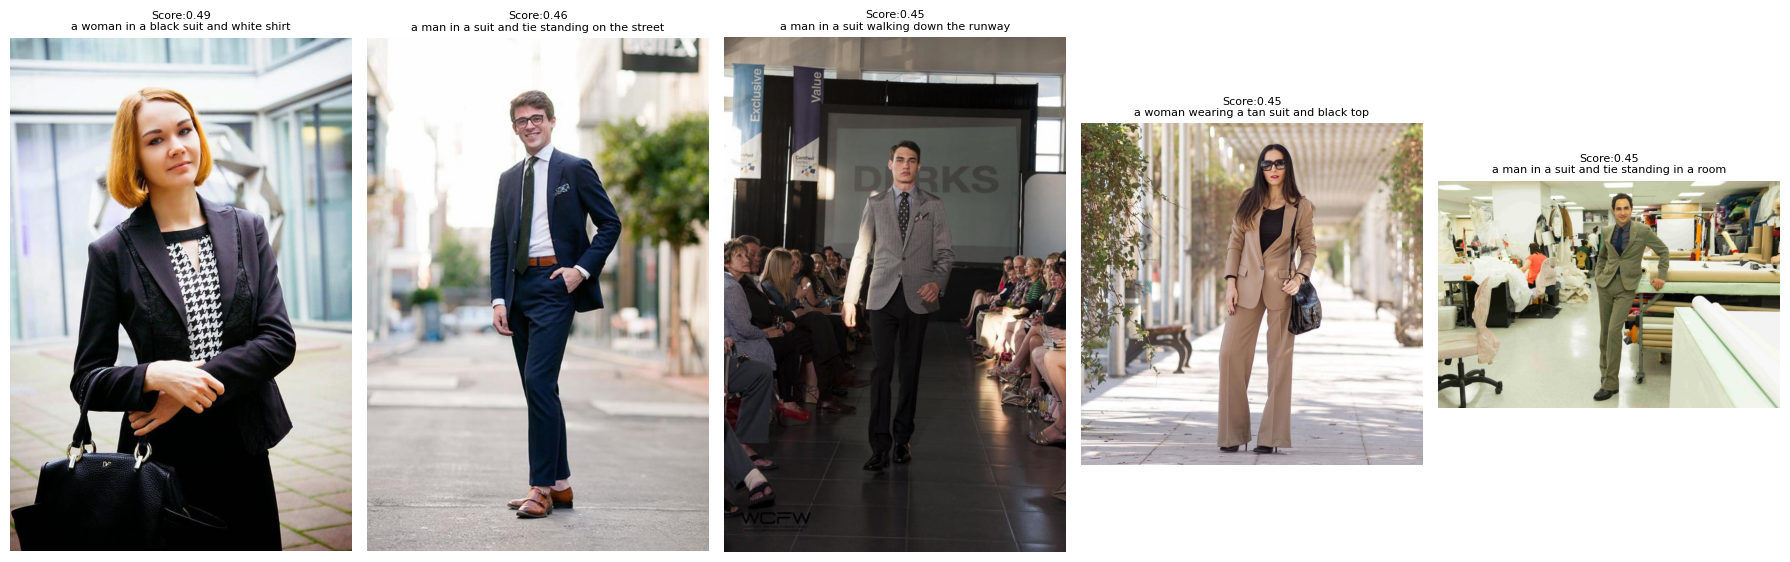

In [32]:
query = "professional business attire inside a modern office"

results = rerank(
    retrieve_candidates(query),
    parse_query(query)
)

show_results(results)

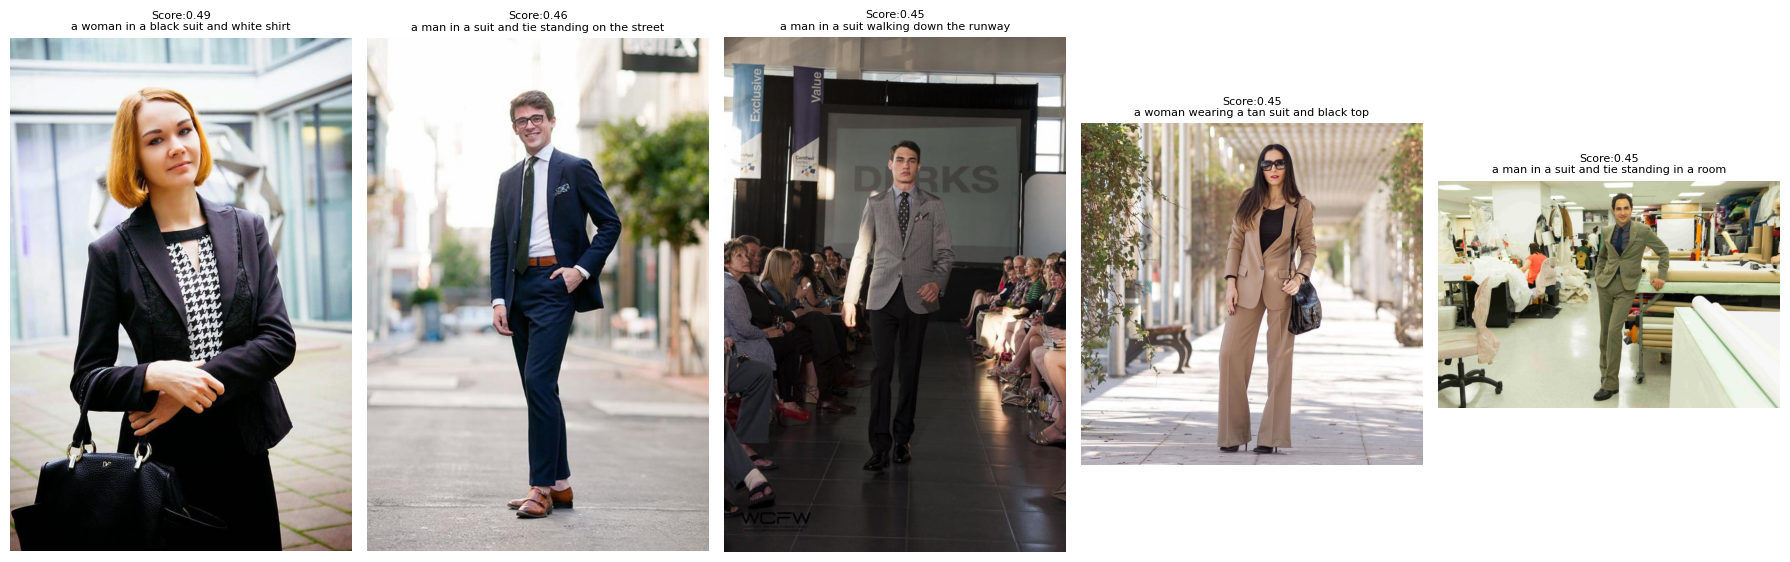

In [ ]:
query = "Professional business attire inside a modern office"

query_info = parse_query(query)

results = rerank(
    retrieve_candidates(query),
    query_info
)

show_results(results)